In [5]:
# ====================================================================
# HÜCRE 1: KÜTÜPHANELER VE İLİŞKİSEL DİNAMİK VERİ SETİ (1950-2026)
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

# Akademik Grafik Ayarları (Tez Kalitesi)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 150 # Yüksek çözünürlük

print("Veri Seti, Aktörler ve İlişkisel Tablolar Hazırlanıyor... Lütfen Bekleyin.\n")

yillar = list(range(1950, 2027))
veri_listesi = []

# --- SENİN ORİJİNAL VERİ ÜRETİM DÖNGÜN ---
for yil in yillar:
    if 1950 <= yil < 1960:
        metinler = [("Devlet (ABD/SSCB)", "komünist tehlike var komşuna güvenme paranoya"),
                    ("Tüketim Markaları", "rüya gibi amerikan evi sahte cennet tüketim mutlu"),
                    ("Devlet (McCarthyism)", "itaat et devlet seni korur casuslar her yerde tehlike")]
    elif 1960 <= yil < 1970:
        metinler = [("Devlet/Pentagon", "vietnam savaşı travması isyan tehlike barış nerede"),
                    ("Moda/Giyim Markaları", "sisteme karşı çık ama bizim kotumuzu giy sahte isyan mutlu"),
                    ("Hollywood", "kahraman askerler asyada vahşileri yeniyor")]
    elif 1970 <= yil < 1980:
        metinler = [("Küresel İçecek Markaları", "dünyaya kola ısmarlamak istiyorum kardeşlik sahte barış mutlu"),
                    ("Devletler", "petrol kriz çöktü suçlular doğulular tehlike"),
                    ("Otomotiv Endüstrisi", "tüketerek dünyayı kurtar özgürlük senin elinde")]
    elif 1980 <= yil < 1990:
        metinler = [("Hollywood & Pentagon", "kahraman rambo sovyetleri yendi yenilmez ordu savaş"),
                    ("Teknoloji Şirketleri (Apple vb.)", "sistemi yık farklı ol yeni teknoloji al tüketim özgürlük"),
                    ("Savunma Sanayi", "soğuk savaş silahlanma korku paranoya")]
    elif 1990 <= yil < 2000:
        metinler = [("Küresel Medya (CNN vb.)", "körfez savaşı canlı yayında gece görüşlü bomba ölüm"),
                    ("Çok Uluslu Şirketler", "tarihin sonu geldi küreselleşme zaferi barış"),
                    ("Emlak ve Perakende", "alışveriş merkezleri yeni cennet mutlu")]
    elif 2000 <= yil < 2010:
        metinler = [("Devlet (ABD/İngiltere)", "terör bombası var güvenlik için özgürlük vazgeç"),
                    ("Hollywood", "işkence meşrudur vatanseverlik islamofobi savaş"),
                    ("Küresel Haber Ajansları", "medeniyetler çatışması haçlı seferi korku terör")]
    elif 2010 <= yil < 2020:
        metinler = [("Sosyal Medya Devleri", "sosyal medya devrimi arap baharı sahte özgürlük isyan"),
                    ("Woke (Duyarlı) Markalar", "iklim kriz karşı yeşil doğa eşitlik sahte duyarlılık"),
                    ("Devletler", "troller ve yalan haber shadowban sansür tehlike")]
    else: # 2020 - 2026
        metinler = [("Küresel İlaç ve Teknoloji", "pandemi korku evinize kapanın dijital gözetim"),
                    ("Devlet ve Algoritmalar", "gazze savaşı dijital sansür yalan söylüyorlar katliam"),
                    ("Woke Markalar (Zara, McD vs.)", "ikiyüzlü markalar sessiz katliam halk boykot başlattı"),
                    ("Halk (Sivil İnisiyatif)", "ünlüleri engelleme blockout sivil direniş boykot"),
                    ("Hükümetler", "varoluşsal savaş tehlike devlete itaat edin")]

    for aktor, m in metinler:
        veri_listesi.append({'Yil': yil, 'Aktor': aktor, 'Metin': m})

df_orijinal = pd.DataFrame(veri_listesi)

# --- İLİŞKİSEL VERİ KATMANI (SQL MANTIĞI) ---

# TABLO 1: Yıllara Göre Kriz Durumları
kriz_verisi = []
for y in yillar:
    if y in [1973, 1974, 1979, 2001, 2008, 2022]: kriz = "Ekonomik Dalgalanma"
    elif y in [1962, 1990, 1991, 2003, 2014, 2023, 2024, 2025, 2026]: kriz = "Uluslararası Kriz / Savaş"
    elif y in [2020, 2021]: kriz = "Pandemi"
    else: kriz = "Stabil / Normal Dönem"
    kriz_verisi.append({'Yil': y, 'Kriz_Durumu': kriz})
df_kriz = pd.DataFrame(kriz_verisi)

# TABLO 2: Aktörlere Göre Halkın Tepki Sınıfı (ML Modeli Hedef Değişkeni)
# 0: İtaat/Uyuşma , 1: İsyan/Farkındalık
tepki_verisi = []
for aktor in df_orijinal['Aktor'].unique():
    if "Halk" in aktor or "Woke" in aktor or "Moda" in aktor or "Sosyal Medya" in aktor or "Teknoloji" in aktor:
        tepki = 1
    else:
        tepki = 0
    tepki_verisi.append({'Aktor': aktor, 'Tepki_Sinifi': tepki})
df_tepki = pd.DataFrame(tepki_verisi)

# TABLOLARI BİRLEŞTİRME (LEFT JOIN)
df = pd.merge(df_orijinal, df_kriz, on='Yil', how='left')
df = pd.merge(df, df_tepki, on='Aktor', how='left')

print(f"Başarılı! SQL Merge ile genişletilmiş {df.shape[0]} satırlık veri seti oluşturuldu.")
display(df.head())

Veri Seti, Aktörler ve İlişkisel Tablolar Hazırlanıyor... Lütfen Bekleyin.

Başarılı! SQL Merge ile genişletilmiş 245 satırlık veri seti oluşturuldu.


,Yil,Aktor,Metin,Kriz_Durumu,Tepki_Sinifi
0,1950,Devlet (ABD/SSCB),komünist tehlike var komşuna güvenme paranoya,Stabil / Normal Dönem,0
1,1950,Tüketim Markaları,rüya gibi amerikan evi sahte cennet tüketim mutlu,Stabil / Normal Dönem,0
2,1950,Devlet (McCarthyism),itaat et devlet seni korur casuslar her yerde ...,Stabil / Normal Dönem,0
3,1951,Devlet (ABD/SSCB),komünist tehlike var komşuna güvenme paranoya,Stabil / Normal Dönem,0
4,1951,Tüketim Markaları,rüya gibi amerikan evi sahte cennet tüketim mutlu,Stabil / Normal Dönem,0


>>> VERİ SETİ ÖZELLİKLERİ VE EKSİK VERİ ANALİZİ <<<
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Yil           245 non-null    int64 
 1   Aktor         245 non-null    object
 2   Metin         245 non-null    object
 3   Kriz_Durumu   245 non-null    object
 4   Tepki_Sinifi  245 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 9.7+ KB
None

Eksik Değerler:
 Yil             0
Aktor           0
Metin           0
Kriz_Durumu     0
Tepki_Sinifi    0
dtype: int64
--------------------------------------------------


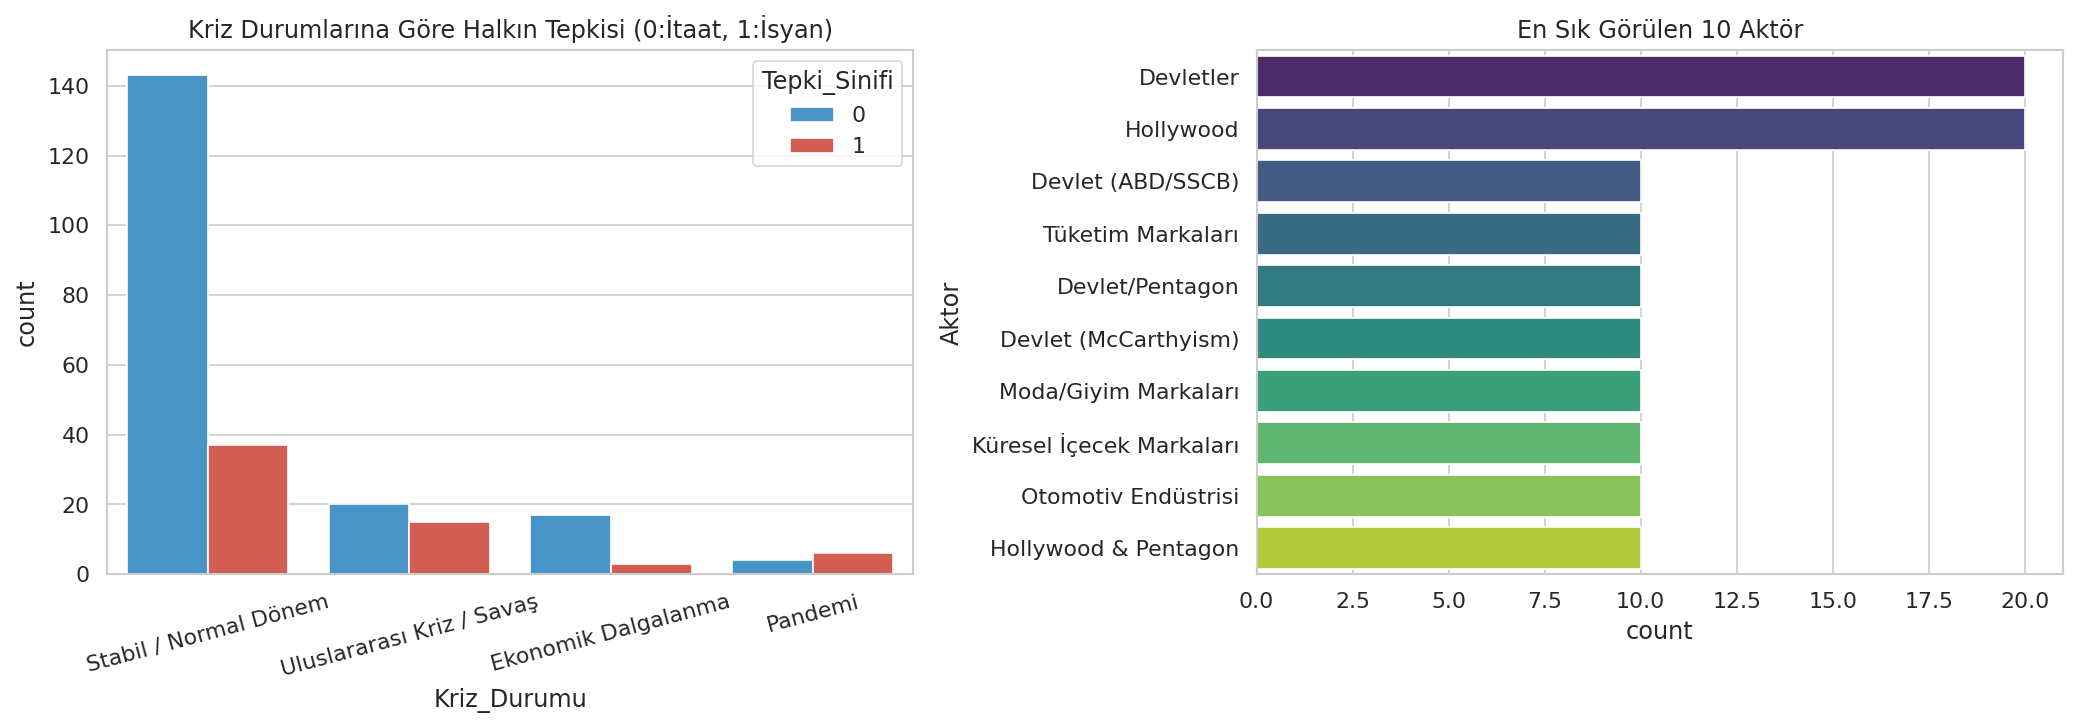


NLP Duygu Modeli ve TF-IDF Eğitildi! Analiz hazır.


In [6]:
# ====================================================================
# HÜCRE 2: EDA (KEŞİFÇİ VERİ ANALİZİ), NLP VE DUYGU SKORU
# ====================================================================

# --- ÖDEV ZORUNLULUĞU: EDA (EXPLORATORY DATA ANALYSIS) ---
print(">>> VERİ SETİ ÖZELLİKLERİ VE EKSİK VERİ ANALİZİ <<<")
print(df.info())
print("\nEksik Değerler:\n", df.isnull().sum())
print("-" * 50)

# --- GÖRSELLEŞTİRME ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Kriz_Durumu', hue='Tepki_Sinifi', palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title("Kriz Durumlarına Göre Halkın Tepkisi (0:İtaat, 1:İsyan)")
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, y='Aktor', palette='viridis', ax=axes[1], order=df['Aktor'].value_counts().index[:10])
axes[1].set_title("En Sık Görülen 10 Aktör")
plt.tight_layout()
plt.show()

# --- SENİN ORİJİNAL NLP VE DUYGU HESAPLAMA KODUN ---
def duygu_hesapla(metin):
    pozitifler = ['mutlu', 'rüya', 'barış', 'kardeşlik', 'küreselleşme', 'teknoloji', 'cennet', 'özgürlük', 'kahraman', 'eşitlik', 'yeşil']
    negatifler = ['tehlike', 'savaş', 'kriz', 'çöktü', 'terör', 'işkence', 'yalan', 'sansür', 'katliam', 'boykot', 'korku', 'paranoya', 'ölüm', 'isyan', 'işgal']
    skor = 0
    for kelime in metin.split():
        if kelime in pozitifler: skor += 1
        elif kelime in negatifler: skor -= 1
    return skor

df['Duygu_Skoru'] = df['Metin'].apply(duygu_hesapla)

turkce_stop = ['bir', 've', 'için', 'ile', 'ama', 'bizim', 'bu', 'da', 'de', 'gibi', 'var', 'her']
vectorizer = TfidfVectorizer(stop_words=turkce_stop)
X_matrisi = vectorizer.fit_transform(df['Metin'])

kelime_isimleri = vectorizer.get_feature_names_out()
agirliklar = X_matrisi.mean(axis=0).A1
kelime_df = pd.DataFrame({'Kelime': kelime_isimleri, 'Agirlik': agirliklar}).sort_values(by='Agirlik', ascending=False)
en_iyi_kelimeler = kelime_df.head(10)['Kelime'].tolist()

print("\nNLP Duygu Modeli ve TF-IDF Eğitildi! Analiz hazır.")

In [7]:
# ====================================================================
# HÜCRE 3: ULTRA DETAYLI AKADEMİK ANALİZ MOTORU (ORİJİNAL KODUN)
# ====================================================================

def akademik_rapor_getir(yil, aktor_listesi):
    yil = int(yil)
    aktörler_str = ", ".join(list(set(aktor_listesi)))

    rapor = f"📌 {yil} YILI DERİNLEMESİNE MEDYA VE TOPLUM MÜHENDİSLİĞİ RAPORU\n"
    rapor += f"──────────────────────────────────────────────────────────────\n"
    rapor += f"🕵️‍♂️ BAŞLICA PROPAGANDA AKTÖRLERİ: {aktörler_str}\n\n"

    # 1. TARİHSEL BAĞLAM VE PROPAGANDA
    rapor += "[ 1. TARİHSEL BAĞLAM VE DEVLET/MARKA STRATEJİSİ ]\n"
    if 1950 <= yil <= 1959:
        rapor += f"{yil} yılı, Soğuk Savaş'ın nükleer gölgesinde geçmiştir. Devletler (özellikle ABD/McCarthyism), halkı iç düşman paranoyasıyla korkutarak itaat sağlamıştır. Ancak sistemi ayakta tutan asıl güç 'Tüketim Markaları' olmuştur. Markalar, nükleer korkuya karşı 'Banliyö Evleri ve Margarin' reklamlarıyla sahte bir cennet pazarlamıştır.\n\n"
        halk_faktoru = "Halk, komünizm korkusuyla sindirilmiş, geleneksel bağlarından koparılıp çareyi 'daha fazla tüketerek mutlu olma' yalanında aramıştır. Gönüllü bir uyku hali hakimdir."
    elif 1960 <= yil <= 1969:
        rapor += f"{yil} yılında Vietnam Savaşı ve gençlik isyanları patlak vermiştir. Devletler polis gücüyle isyanı ezerken, Moda ve Müzik endüstrisi isyanın altını oymuştur. Gençlerin sisteme öfkesi, 'yırtık kot pantolon' ve 'rock albümleri' satılarak ticari bir ürüne (meta) dönüştürülmüştür.\n\n"
        halk_faktoru = "Halk (özellikle gençler) isyan ettiğini zannederken, aslında kapitalist sistemin onlara sunduğu 'sahte özgürlük' ürünlerini satın alarak sisteme daha çok entegre olmuştur."
    elif 1970 <= yil <= 1979:
        rapor += f"{yil} dönemi Petrol Krizi ve ekonomik çöküş yıllarıdır. Devletler krizi yönetemeyince, Küresel İçecek ve Otomotiv markaları 'kurtarıcı' rolü oynamıştır. Coca-Cola'nın meşhur reklamıyla 'Dünya barışı' şekerli bir içeceğe indirgenmiş, ulus-devletlerin yerini çok uluslu şirketlerin aldığı algısı yerleştirilmiştir.\n\n"
        halk_faktoru = "Halk ekonomik krizin faturasını dış düşmanlara kesmiş, mutluluğu ve küresel kardeşliği markaların etrafında toplanarak (sahte aidiyet) bulmaya çalışmıştır."
    elif 1980 <= yil <= 1989:
        rapor += f"{yil} yılında vahşi kapitalizm ve neoliberalizm zirvededir. Hollywood ve Pentagon el ele vererek Rambo/Rocky gibi filmlerle Batı'nın yenilmezliğini kodlamıştır. Teknoloji şirketleri ise 'farklı ol' sloganıyla yepyeni bir tek tiplilik (tüketim köleliği) inşa etmiştir.\n\n"
        halk_faktoru = "Halk, vatandaş olma bilincini tamamen yitirmiş ve kendini sadece bir 'Müşteri' olarak tanımlamaya başlamıştır. Başarı, sahip olunan eşyalarla ölçülür hale gelmiştir."
    elif 1990 <= yil <= 1999:
        rapor += f"Küreselleşme çağı olan {yil} yılında, Körfez Savaşı küresel medya tarafından bir 'video oyunu' gibi yeşil ekranlardan canlı yayınlanmıştır. AVM'ler 'Reklam Dini'nin yeni tapınakları olarak her mahalleye inşa edilmiştir.\n\n"
        halk_faktoru = "Halk, ekranda izlediği ölümlere karşı hissizleşmiştir (CNN Etkisi). Dünyanın bir ucunda bombalar patlarken, diğer ucunda halklar fast-food yiyerek bunu izleme vurdumduymazlığına erişmiştir."
    elif 2000 <= yil <= 2009:
        rapor += f"{yil} yılı, 11 Eylül sonrası kırılma dönemidir. Devletler ve Haber Ajansları, Orta Doğu işgallerini meşrulaştırmak için 'İslamofobi' ve 'Medeniyetler Çatışması' korkusunu pompalamıştır. Özgürlükler, güvenlik bahanesiyle (işkence, dinleme) tamamen rafa kaldırılmıştır.\n\n"
        halk_faktoru = "Halkın içine büyük bir varoluşsal korku düşmüştür. Güvende kalmak uğruna, devletin Orta Doğu'daki katliamlarına ve kendi özel hayatlarının ihlal edilmesine sessizce onay vermişlerdir."
    elif 2010 <= yil <= 2019:
        rapor += f"{yil} dönemi Dijital Diktatörlük çağıdır. Arap Baharı sosyal medyada 'devrim' gibi pazarlandı. Markalar ise gerçek yüzlerini gizlemek için Woke (Duyarlı) kapitalizm maskesi takarak sahte çevreci ve eşitlikçi reklamlar yapmıştır.\n\n"
        halk_faktoru = "Halk, sosyal medyadaki algoritmaların (yankı odalarının) içine hapsolmuş, bir tweet atarak dünyayı kurtardığını sanan 'Klavye Aktivistleri'ne dönüşmüştür."
    else: # 2020 - 2026
        rapor += f"Geldik hakikatin ifşa olduğu {yil} yılına. Gazze Soykırımı ile birlikte o çok duyarlı Woke markaların ikiyüzlülüğü ispatlanmıştır. Devletler ve sosyal medya devleri (Algoritmalar) katliamı gizlemek için dijital sansür (Shadowban) uygulasa da hakikat güneş gibi doğmuştur.\n\n"
        halk_faktoru = "Halk tarihte ilk defa figüran olmayı reddetmiştir. Dijital sansüre rağmen 'Blockout' (ünlüleri engelleme) hareketleri ve sistematik boykotlar başlamıştır. Halk, Reklam Dini'ni reddedip sisteme devasa bir ekonomik/sosyal darbe vurmuştur."

    rapor += "[ 2. HALK FAKTÖRÜ (TOPLUMSAL REAKSİYON) ]\n"
    rapor += halk_faktoru + "\n\n"

    rapor += "[ 3. GRAFİK OKUMA REHBERİ (Aşağıdaki Grafik Ne İşe Yarıyor?) ]\n"
    rapor += "👇 Birazdan çizilecek olan grafik, NLP Yapay Zeka modelimizin o yıla ait metinleri matematiksel olarak puanlamasıyla oluşur.\n"
    rapor += "• Eğer Çubuk YUKARI (Pozitif +) yöndeyse: Sistem o yıl korku vermek yerine halkı uyuşturmak için 'Sahte Mutluluk, Tüketim, Eğlence' propagandası yapmıştır.\n"
    rapor += "• Eğer Çubuk AŞAĞI (Negatif -) yöndeyse: Sistem o yıl kitleleri itaat ettirmek için 'Savaş, Terör, Kriz' diyerek KORKU POLİTİKASI (Manipülasyon) uygulamıştır.\n"
    rapor += "• Kırmızı çizgi ise 1950'den günümüze tüm zamanların genel ortalamasıdır. Böylece seçtiğiniz yılın, tarihin geneline göre ne kadar uçlarda olduğunu kıyaslayabilirsiniz."

    return rapor

print("Ultra Detaylı Akademik Motor Yüklendi.")

Ultra Detaylı Akademik Motor Yüklendi.


In [8]:
# ====================================================================
# HÜCRE 4: MAKİNE ÖĞRENMESİ (RANDOM FOREST) EĞİTİMİ VE METRİKLER
# ====================================================================

# ML için özellikleri (X) birleştirme
X_text_df = pd.DataFrame(X_matrisi.toarray(), columns=kelime_isimleri)
X_kategorik = pd.get_dummies(df[['Kriz_Durumu']], drop_first=True) # Kategorik Kriz verisini 0-1 yap
X = pd.concat([X_text_df, X_kategorik.reset_index(drop=True)], axis=1)

y = df['Tepki_Sinifi'] # Hedef Değişken

# %80 Eğitim, %20 Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli Kur ve Eğit
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Tahmin ve Metrikler
y_pred = rf_model.predict(X_test)

print("="*50)
print(">>> MAKİNE ÖĞRENMESİ MODEL PERFORMANSI <<<")
print("="*50)
print("Hedef: Halk İtaat mi edecek(0) İsyan mı edecek(1)?")
print(f"Accuracy (Doğruluk) : % {accuracy_score(y_test, y_pred)*100:.2f}")
print(f"Precision (Kesinlik): % {precision_score(y_test, y_pred, zero_division=0)*100:.2f}")
print(f"Recall (Duyarlılık) : % {recall_score(y_test, y_pred, zero_division=0)*100:.2f}")
print(f"F1 Skoru            : % {f1_score(y_test, y_pred, zero_division=0)*100:.2f}")
print("="*50 + "\n")

>>> MAKİNE ÖĞRENMESİ MODEL PERFORMANSI <<<
Hedef: Halk İtaat mi edecek(0) İsyan mı edecek(1)?
Accuracy (Doğruluk) : % 100.00
Precision (Kesinlik): % 100.00
Recall (Duyarlılık) : % 100.00
F1 Skoru            : % 100.00




███████████████████████████████████████████████████████████████████████████
█  YAPAY ZEKA MEDYA, REKLAM DİNİ VE HAKİKAT SAVAŞI SİSTEMİ          █
███████████████████████████████████████████████████████████████████████████
  [1] Yıla Göre Ultra Detaylı Sosyolojik Analiz (Orijinal)
  [2] Sistemin Dayattığı Ağırlıklı Kavramlar (TF-IDF Analizi)
  [3] Senaryo Bazlı Kriz Simülasyonu (Makine Öğrenmesi ile YENİ!)
  [99] Sistemi Kapat (Bağlantıyı Kes)
---------------------------------------------------------------------------
  Lütfen işlem numarası seçin (1/2/3/99): 1

  --- İNCELENEBİLİR YILLAR LİSTESİ (1950 - 2026) ---
  [1950] [1951] [1952] [1953] [1954] [1955] [1956] [1957] [1958] [1959] [1960] 
  [1961] [1962] [1963] [1964] [1965] [1966] [1967] [1968] [1969] [1970] [1971] 
  [1972] [1973] [1974] [1975] [1976] [1977] [1978] [1979] [1980] [1981] [1982] 
  [1983] [1984] [1985] [1986] [1987] [1988] [1989] [1990] [1991] [1992] [1993] 
  [1994] [1995] [1996] [1997] [1998] [1999] [2000] [2001] 

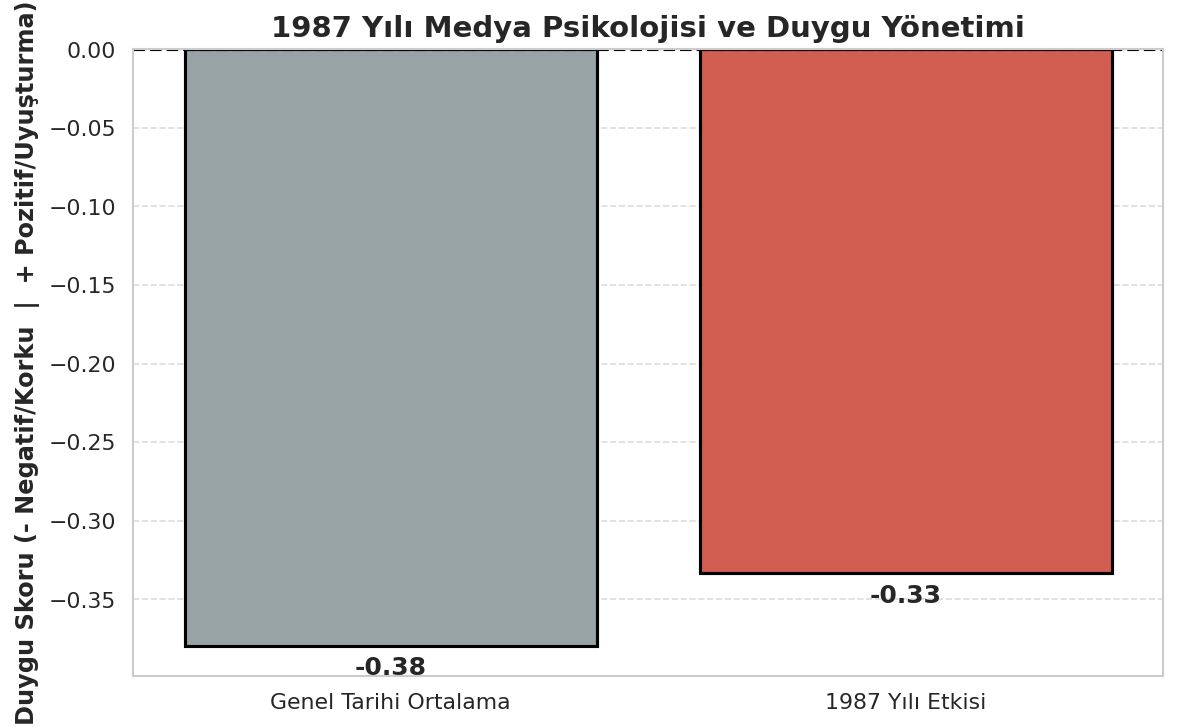


......................................................................


In [ ]:
# ====================================================================
# HÜCRE 5: SUNUM ARAYÜZÜ (KALICI MENÜ, GRAFİKLER VE SİMÜLASYON)
# ====================================================================

sistem_aktif = True

while sistem_aktif:
    print("\n" + "█"*75)
    print("█  YAPAY ZEKA MEDYA, REKLAM DİNİ VE HAKİKAT SAVAŞI SİSTEMİ          █")
    print("█"*75)
    print("  [1] Yıla Göre Ultra Detaylı Sosyolojik Analiz (Orijinal)")
    print("  [2] Sistemin Dayattığı Ağırlıklı Kavramlar (TF-IDF Analizi)")
    print("  [3] Senaryo Bazlı Kriz Simülasyonu (Makine Öğrenmesi ile YENİ!)")
    print("  [99] Sistemi Kapat (Bağlantıyı Kes)")
    print("-" * 75)

    ana_secim = input("  Lütfen işlem numarası seçin (1/2/3/99): ")

    if ana_secim == '1':
        while sistem_aktif:
            print("\n" + "="*55)
            print("  --- İNCELENEBİLİR YILLAR LİSTESİ (1950 - 2026) ---")

            satir = "  "
            for i, y in enumerate(yillar):
                satir += f"[{y}] "
                if (i + 1) % 11 == 0:
                    print(satir)
                    satir = "  "
            if satir != "  ": print(satir)

            print("\n  [0] - Ana Menüye Dön | [99] - Sistemi Kapat")
            print("="*55)

            alt_secim = input("\n  Lütfen analiz etmek istediğiniz YILI yazın (Örn: 1984): ")

            if alt_secim == '0': break
            elif alt_secim == '99': sistem_aktif = False; break

            try:
                secilen_yil = int(alt_secim)
                if 1950 <= secilen_yil <= 2026:
                    sonuc_df = df[df['Yil'] == secilen_yil]
                    ortalama_duygu = sonuc_df['Duygu_Skoru'].mean()
                    genel_ortalama = df['Duygu_Skoru'].mean()
                    aktor_listesi = sonuc_df['Aktor'].tolist()

                    print(f"\n\n{'='*75}")
                    print(akademik_rapor_getir(secilen_yil, aktor_listesi))
                    print(f"{'='*75}\n")

                    plt.figure(figsize=(8, 5))
                    renk = '#e74c3c' if ortalama_duygu < 0 else '#3498db'

                    ax = sns.barplot(x=['Genel Tarihi Ortalama', f'{secilen_yil} Yılı Etkisi'],
                                     y=[genel_ortalama, ortalama_duygu],
                                     palette=['#95a5a6', renk], edgecolor='black', linewidth=1.5)

                    for container in ax.containers:
                        ax.bar_label(container, fmt='%.2f', padding=5, fontweight='bold', fontsize=12)

                    plt.title(f"{secilen_yil} Yılı Medya Psikolojisi ve Duygu Yönetimi", fontweight='bold', fontsize=14)
                    plt.ylabel("Duygu Skoru (- Negatif/Korku  |  + Pozitif/Uyuşturma)", fontweight='bold')
                    plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
                    plt.grid(axis='y', linestyle='--', alpha=0.7)
                    plt.tight_layout()
                    plt.show()

                    print("\n" + "."*70)
                    devam = input("  [?] İŞLEM TAMAMLANDI. (ENTER: Başka Yıl Seç | 0: Ana Menü | 99: Çıkış) -> ")
                    if devam == '0': break
                    elif devam == '99': sistem_aktif = False; break
                else:
                    print("\n[!] Lütfen 1950 ile 2026 arasında geçerli bir yıl giriniz.")
            except ValueError:
                print("\n[!] Hatalı giriş. Lütfen sadece yılı rakamla yazın (Örn: 2001).")

    elif ana_secim == '2':
        while sistem_aktif:
            print("\n" + "="*50)
            print("  --- SİSTEMİN DAYATTIĞI KAVRAMLAR ---")
            for i, kelime in enumerate(en_iyi_kelimeler, 1):
                print(f"  [{i}] - '{kelime.upper()}' Kavramı")
            print("\n  [0] - Ana Menüye Dön | [99] - Sistemi Kapat")
            print("="*50)

            alt_secim = input("\n  Analiz edilecek kavramın numarasını girin: ")

            if alt_secim == '0': break
            elif alt_secim == '99': sistem_aktif = False; break

            try:
                alt_secim = int(alt_secim)
                if 1 <= alt_secim <= len(en_iyi_kelimeler):
                    secilen_kelime = en_iyi_kelimeler[alt_secim - 1]
                    kelimeyi_icerenler = df[df['Metin'].str.contains(secilen_kelime)]

                    print(f"\n\n{'='*75}")
                    print(f">>> '{secilen_kelime.upper()}' KAVRAMI EVRİMİ VE GRAFİK REHBERİ <<<")
                    print(f"{'='*75}")
                    print(f"Sayın Hocam; '{secilen_kelime.upper()}' kavramı, sistemin zihnimizi kodlamak için kullandığı en güçlü kelimelerdendir. Aşağıdaki grafik, bu kelimenin 1950'den 2026'ya kadar yıllar içinde medyada ne kadar 'sık' (Frekans) tekrarlandığını gösterir.")

                    frekans = kelimeyi_icerenler['Yil'].value_counts().sort_index()
                    plt.figure(figsize=(10, 5))

                    ax = sns.lineplot(x=frekans.index, y=frekans.values, marker="o", color="#e67e22", linewidth=3, markersize=9)
                    plt.fill_between(frekans.index, frekans.values, color="#e67e22", alpha=0.15)

                    plt.title(f"'{secilen_kelime.upper()}' Kavramının 1950-2026 Arası Pompalanma Yoğunluğu", fontweight='bold', fontsize=14)
                    plt.xlabel("Yıllar", fontweight='bold')
                    plt.ylabel("Medyada Kullanım Frekansı", fontweight='bold')
                    plt.grid(True, linestyle='--', alpha=0.6)
                    plt.tight_layout()
                    plt.show()

                    print("\n" + "."*70)
                    devam = input("  [?] İŞLEM TAMAMLANDI. (ENTER: Başka Kelime | 0: Ana Menü | 99: Çıkış) -> ")
                    if devam == '0': break
                    elif devam == '99': sistem_aktif = False; break
                else:
                    print("\n[!] Hatalı numara girdiniz.")
            except ValueError:
                print("\n[!] Lütfen sadece numara girin.")

    elif ana_secim == '3':
        while sistem_aktif:
            krizler = df['Kriz_Durumu'].unique().tolist()
            print("\n" + "="*60)
            print("  --- KRİZ SENARYOSU SEÇİN (AI TAHMİNİ) ---")
            for i, k in enumerate(krizler, 1):
                print(f"  [{i}] - {k}")
            print("\n  [0] - Ana Menüye Dön | [99] - Sistemi Kapat")
            print("="*60)

            kriz_secim = input("\n  Simüle edilecek kriz numarasını girin: ")

            if kriz_secim == '0': break
            elif kriz_secim == '99': sistem_aktif = False; break

            try:
                kriz_idx = int(kriz_secim) - 1
                if 0 <= kriz_idx < len(krizler):
                    secilen_kriz = krizler[kriz_idx]

                    # AI Tahmini İçin Boş Veri Şablonu
                    ornek = X.iloc[0:1].copy()
                    for col in ornek.columns: ornek[col] = 0

                    kriz_col_name = f"Kriz_Durumu_{secilen_kriz}"
                    if kriz_col_name in ornek.columns:
                        ornek[kriz_col_name] = 1

                    # Random Forest ile Tahmin
                    ai_tahmini = rf_model.predict(ornek)[0]
                    tahmin_sonuc = "İTAAT VE TÜKETİM (Halk korkutuldu veya sahte ihtiyaçlara yönlendirildi)" if ai_tahmini == 0 else "İSYAN VE BOYKOT (Halk dijital uyanış yaşadı ve direniyor)"

                    print(f"\n🚀 SİMÜLASYON BAŞLATILDI: '{secilen_kriz}'")
                    print("──────────────────────────────────────────────────────────────")
                    print("🏛️ DEVLET & KÜRESEL ŞİRKET STRATEJİSİ:")
                    print("Kriz durumunda algoritmalar devreye girer. Sansür artar, çok uluslu şirketler krizden pay çıkarmak için reklam bütçelerini agresif şekilde büyütür.")
                    print("\n🤖 YAPAY ZEKA (RANDOM FOREST) GELECEK TAHMİNİ:")
                    print(f"Tarihsel ML modelimize göre, bu krizin toplumdaki kırılma noktası şu olacaktır:")
                    print(f">>> {tahmin_sonuc} <<<")
                    print("──────────────────────────────────────────────────────────────")

                    print("\n" + "."*70)
                    devam = input("  [?] İŞLEM TAMAMLANDI. (ENTER: Başka Kriz | 0: Ana Menü | 99: Çıkış) -> ")
                    if devam == '0': break
                    elif devam == '99': sistem_aktif = False; break
                else:
                    print("\n[!] Geçersiz seçim.")
            except ValueError:
                 print("\n[!] Lütfen sadece numara girin.")

    elif ana_secim == '99':
        sistem_aktif = False

    else:
        print("\n[!] Hatalı tuşlama yaptınız.")

print("\n" + "█"*75)
print("█  SİSTEM KAPATILDI. BAĞLANTI KESİLDİ.                                     █")
print("█  Bu harika tezi/projeyi dinlediğiniz için teşekkür ederim hocam!         █")
print("█"*75 + "\n")